In [1]:
# 1. Import Libraries

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [ ]:
# 2. Download Dataset

path = kagglehub.dataset_download("marius2303/medical-condition-prediction-dataset")
print("Dataset Path:", path)

# Load CSV file (auto-detect)
import os
files = os.listdir(path)
print("Files:", files)

# Assuming single CSV file
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

print("\nFirst 5 rows:\n", df.head())

Dataset Path: C:\Users\.cache\kagglehub\datasets\marius2303\medical-condition-prediction-dataset\versions\4
Files: ['medical_conditions_dataset.csv']

First 5 rows:
    id full_name   age gender smoking_status        bmi  blood_pressure  \
0   1  User0001   NaN   male     Non-Smoker        NaN             NaN   
1   2  User0002  30.0   male     Non-Smoker        NaN      105.315064   
2   3  User0003  18.0   male     Non-Smoker  35.612486             NaN   
3   4  User0004   NaN   male     Non-Smoker        NaN       99.119829   
4   5  User0005  76.0   male     Non-Smoker        NaN             NaN   

   glucose_levels  condition  
0             NaN  Pneumonia  
1             NaN   Diabetic  
2             NaN  Pneumonia  
3             NaN  Pneumonia  
4             NaN   Diabetic  


In [3]:
# 3. Data Preprocessing

# Handle missing values
imputer = SimpleImputer(strategy="mean")
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = imputer.fit_transform(df[num_cols])

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [4]:
# 4. Feature & Target Split

X = df.drop("condition", axis=1)
y = df["condition"]

# 5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 6. Models

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Gradient Boosting
gb = GradientBoostingClassifier()

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Voting Ensemble
voting = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    voting='hard'
)

In [6]:
# 7. Train Models

models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "Voting Ensemble": voting
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Random Forest Accuracy: 0.5565
Gradient Boosting Accuracy: 0.6055


c:\Users\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:15:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.5835


c:\Users\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:15:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Voting Ensemble Accuracy: 0.6010


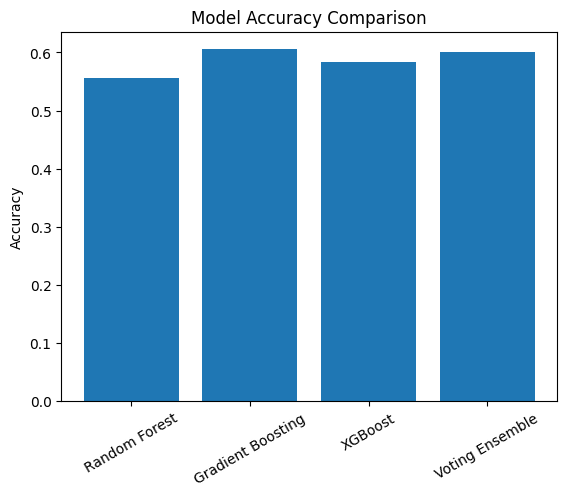

In [7]:
# 8. Accuracy Comparison Graph

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

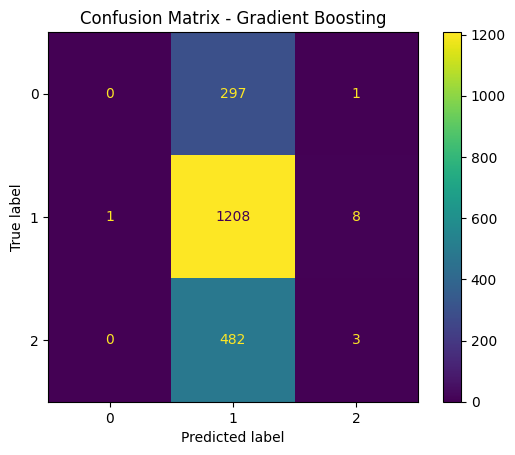

In [8]:
# 9. Confusion Matrix 

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

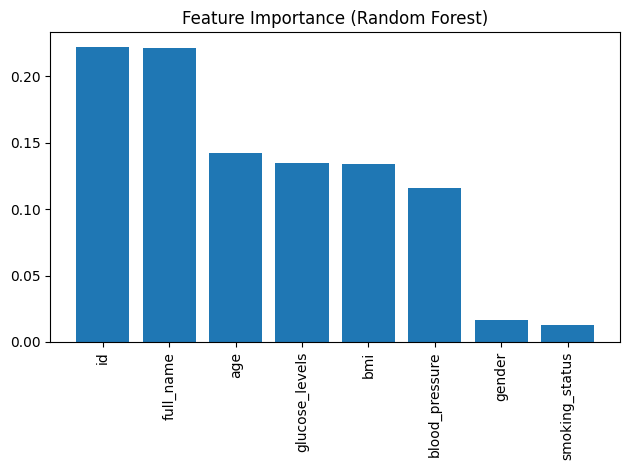

In [9]:
# 10. Feature Importance (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

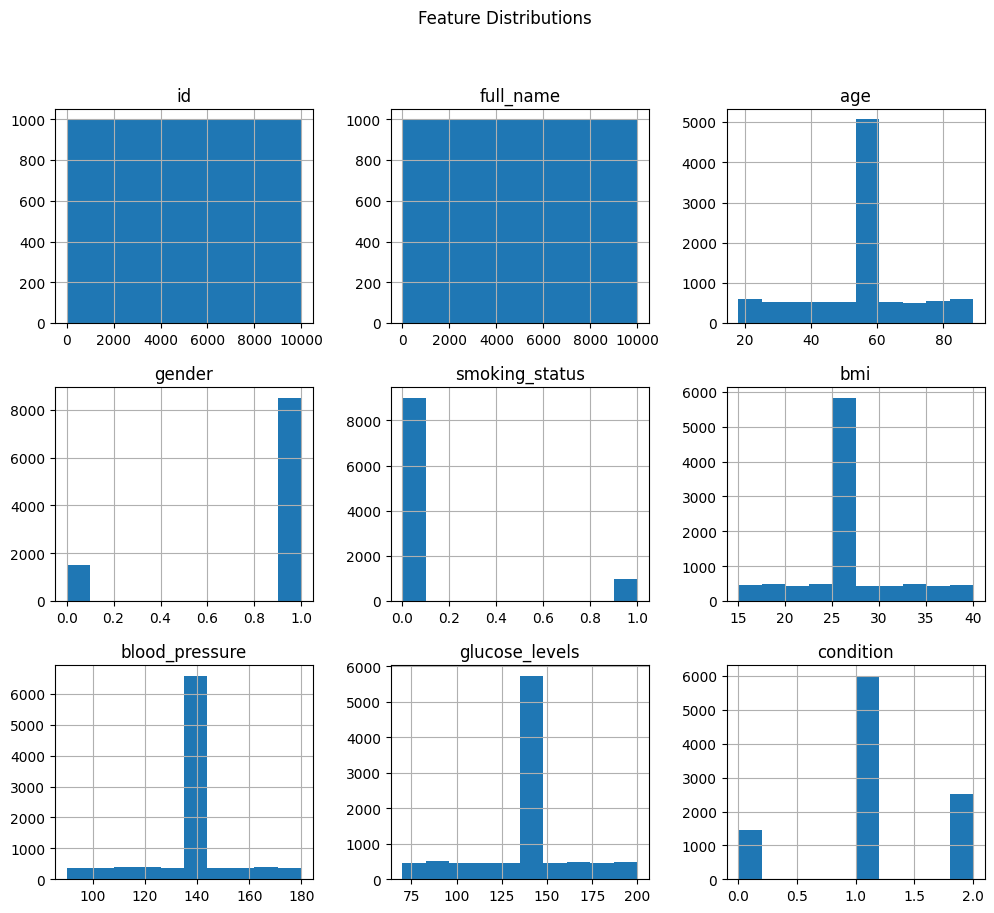

In [10]:
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions")
plt.show()

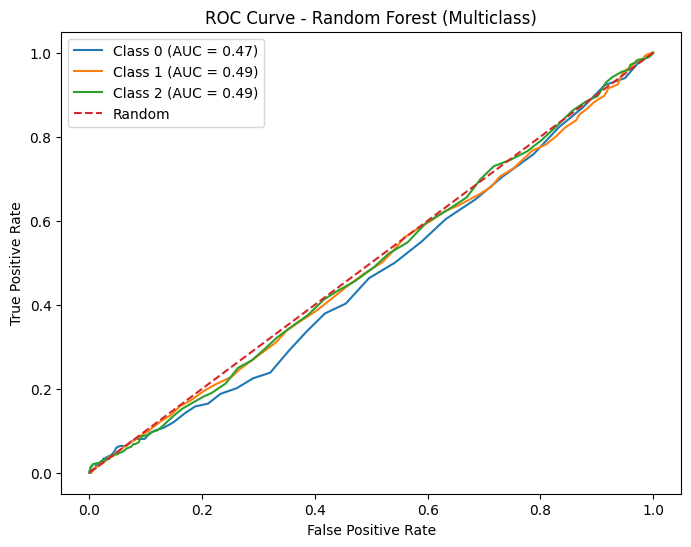

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Example for Random Forest (multiclass ROC)
y_prob = rf.predict_proba(X_test)
n_classes = len(np.unique(y_test))

# Binarize the output for multiclass
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(8, 6))

for i in range(n_classes):
	fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
	roc_auc = auc(fpr, tpr)
	plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.title("ROC Curve - Random Forest (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#Checking with SVM

In [12]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', probability=True, random_state=42)

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
svm = SVC(probability=True)

voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb),
        ('svm', svm)
    ],
    voting='soft'
)

In [14]:
models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "SVM": svm,
    "Voting Ensemble": voting
}

In [15]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc   # VERY IMPORTANT

c:\Users\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:16:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:16:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
print(results)

{'Random Forest': 0.5565, 'Gradient Boosting': 0.6055, 'XGBoost': 0.5835, 'SVM': 0.6085, 'Voting Ensemble': 0.6055}


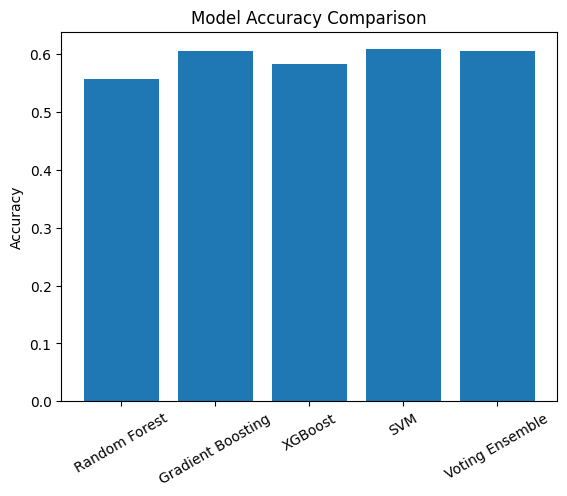

In [ ]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()